In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.optimize as opt
from scipy.special import factorial 
from scipy import stats
import pandas as pd

import util


plt.rc('text', usetex=True)
plt.rc('font', family='serif')

plt.figure(figsize=(10,6), dpi=300)

<Figure size 3000x1800 with 0 Axes>

<Figure size 3000x1800 with 0 Axes>

In [2]:
# Draw samples from a poissonian distribution
# use pandas to open pendulumData (1).csv
df = pd.read_csv("pendulumData (1).csv")
cutoff = 10

#print columns
print(df.columns)
# need explanation 
def iqr(data):
    q75, q25 = np.percentile(data, [75 ,25])
    iqr = q75 - q25
    return iqr

iqr_val = iqr(df['g (m/s2)'])

median  = df['g (m/s2)'].median()

pendulum_data = df[np.abs(df['g (m/s2)'] - median) <= iqr_val*cutoff]
pendulum_data_outliers = df[np.abs(df['g (m/s2)'] - median) >= iqr_val*cutoff]

print(pendulum_data_outliers)
counts = pendulum_data[r'g (m/s2)']

# get statistics
mean = counts.mean()
std = counts.std()
err = std/np.sqrt(len(counts))
print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Standard error: {err :.2f}")




Index(['label', 'g (m/s2)', 'stat uncert', 'sys uncert', 'total uncert'], dtype='str')
               label  g (m/s2) stat uncert sys uncert total uncert
4    20.Sep.X.B01.05    978.00          17          8          NaN
50   21.Sep.A.B02.08     12.22        1.29       1.22          NaN
68   21.Sep.A.B04.03     14.60         NaN        NaN          5.3
89   21.Sep.B.B02.07     12.22        1.29       1.22          NaN
226  23.Feb.A.B02.02     15.70         NaN        NaN          3.9
270  23.Sep.A.B02.09      6.95         NaN        NaN         1.07
347  24.Feb.A.B01.04     14.64         NaN        NaN         3.82
370  24.Sep.A.B01.09     12.83         NaN        NaN         1.74
390  24.Sep.A.B03.09     12.40         NaN        NaN          0.3
404  24.Sep.A.B04.11     12.82         NaN        NaN         0.13
466   25.Feb.A.B02.9      0.60         0.1       0.09         0.19
503   25.Sep.A.B03.1     13.00           2        NaN          NaN
510   25.Sep.A.B03.8     13.22         NaN

In [3]:

popt, uncert, bin_centers, freqs, sig, bins, normalization, chi2, dof, chi2_probs = \
    util.fit_gaussian(counts, bins=50, p0=[9.8, 1, 0.2])

mean = popt[0]
std = popt[2]
err = std/np.sqrt(len(counts))
precision = max(0, -int(np.floor(np.log10(abs(err)))))
x = np.linspace(start=np.min(counts), stop=np.max(counts), num=1000, endpoint=True)

print(f'popt:  {popt}')
print(f'uncert: {uncert}')
print(f'chi2={chi2:.4f}, dof={dof}, p={chi2_probs:.4f}')
print(f'uncertainty: {err:.{precision}f}')
print(f'error from expected value: {abs((mean-9.804)/err):.{precision}f}')


popt:  [9.79352477 1.         0.16952526]
uncert: [0.00861589 0.03539673 0.00825478]
chi2=168.6749, dof=36, p=0.0000
uncertainty: 0.007
error from expected value: 1.457


In [4]:
def plot_histogram(ax, bin_centers, freqs, normalization, bins, **kwargs):
    """Fill a histogram bin-by-bin, leaving gaps between non-adjacent bins."""
    bw = bins[1] - bins[0]
    x_fill = np.array([[c - bw/2, c + bw/2, np.nan] for c in bin_centers]).ravel()
    y_fill = np.array([[f, f, np.nan] for f in freqs * normalization]).ravel()
    ax.fill_between(x_fill, y_fill, **kwargs)

def add_stats_annotation(ax, chi2, dof, chi2_probs, n_counts, n_bins, bw, unit='', fontsize=8):
    """Add a left-aligned stats block to the top-left of ax."""
    stats_text = '\n'.join([
        f'$N={n_counts}$, bins $={n_bins}$',
        r'$\chi^2$/dof $= {:.2f} / {}$'.format(chi2,dof, chi2_probs),
        r'$p = {:.2f}$'.format(chi2_probs),
    ])
    ax.text(0.04, 0.95, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=fontsize)


In [5]:
from scipy.integrate import quad

integral, error = quad(util.gaussian, np.min(counts), np.max(counts), args=tuple(popt), points=[popt[0]])
print(f"Integral of fitted Gaussian: {integral:.6f} ± {error:.2e}")


Integral of fitted Gaussian: 1.000000 ± 9.08e-13


<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/tmp/ipykernel_4855/1279203873.py:20: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax1.axvline(mean, color='black', linestyle='--', linewidth=lw, label=f'$\mu$: {mean:.{precision}f} $\\pm$ {uncert[0]:.{precision}f} m/s$^2$')
/tmp/ipykernel_4855/1279203873.py:21: SyntaxWarning: "\

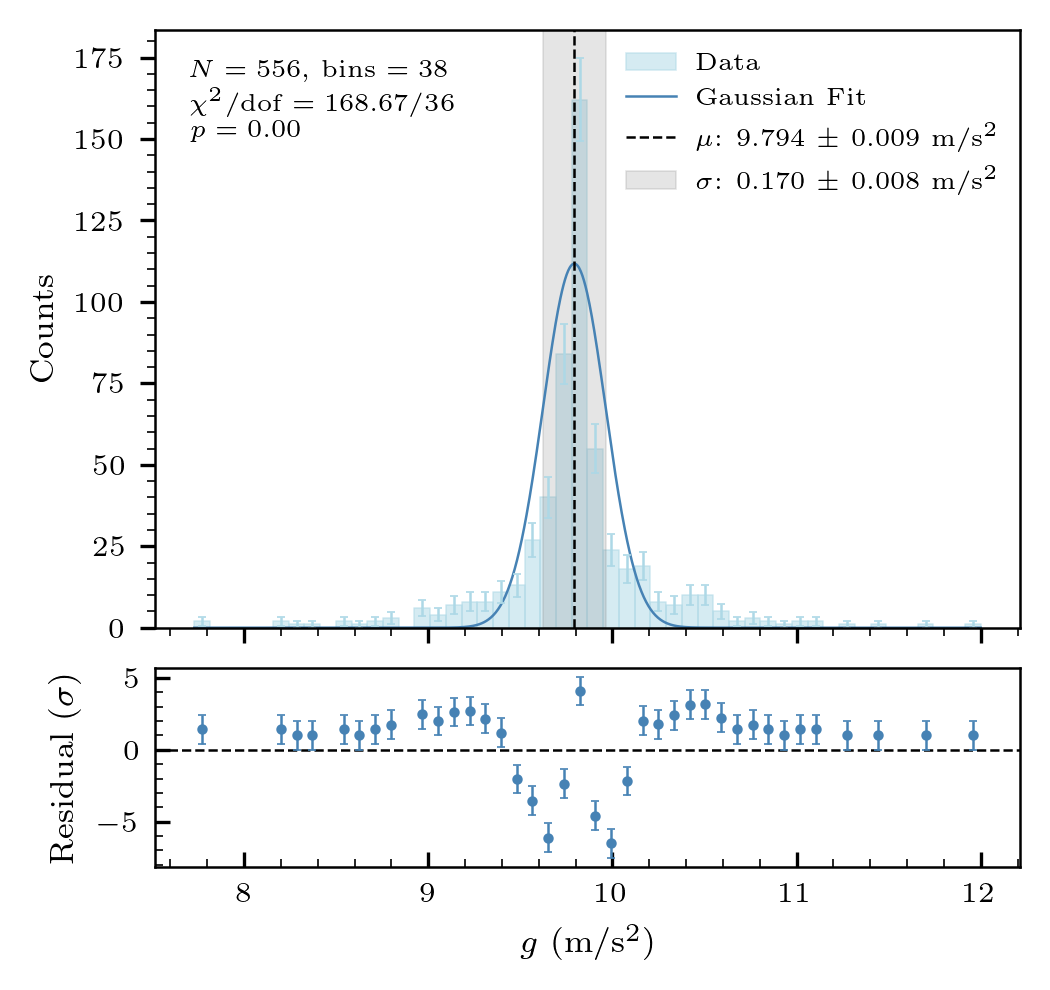

In [6]:

capsize = 1
capthick = 0.4
lw = 0.6
hist_lw = 0.4
span_lw = 0.4
ms = 1.5
spine_lw = 0.6
data_color = 'lightblue'
accent_color = 'steelblue'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.6, 3.4), dpi=300,
                                sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

plot_histogram(ax1, bin_centers, freqs, normalization, bins, color=data_color, alpha=0.5, linewidth=hist_lw, label='Data')
ax1.plot(x, util.gaussian(x, *popt) * normalization, linewidth=lw, color=accent_color, label='Gaussian Fit')
ax1.errorbar(bin_centers, freqs * normalization, yerr=sig * normalization, linewidth=lw, ls='none', fmt='', capsize=capsize, capthick=capthick, color=data_color)

ax1.set_ylabel(r'Counts', fontsize=8)
ax1.axvline(mean, color='black', linestyle='--', linewidth=lw, label=f'$\mu$: {mean:.{precision}f} $\\pm$ {uncert[0]:.{precision}f} m/s$^2$')
ax1.axvspan(mean - std, mean + std, color='gray', alpha=0.2, linewidth=span_lw, label=f'$\sigma$: {std:.{precision}f} $\\pm$ {uncert[2]:.{precision}f} m/s$^2$')
leg = ax1.legend(frameon=False, fontsize=6, loc='upper right')
for text in leg.get_texts():
    text.set_ha('right')
ax1.set_ylim(bottom=0)
ax1.tick_params(labelsize=7, direction='out', which='major')
ax1.tick_params(direction='out', which='minor', length=2, width=0.4)
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
for spine in ax1.spines.values():
    spine.set_linewidth(spine_lw)

add_stats_annotation(ax1, chi2, dof, chi2_probs, len(counts), len(bin_centers), bins[1] - bins[0], unit='m/s$^2$', fontsize=6)

ax2.axhline(0, color='black', linestyle='--', linewidth=lw)

residuals = (freqs - util.gaussian(bin_centers, *popt)) / sig
ax2.plot(bin_centers, residuals, marker='o', markersize=ms, linestyle='none', color=accent_color)
ax2.errorbar(bin_centers, residuals, yerr=sig/sig, linewidth=lw, ls='none', fmt='', capsize=capsize, capthick=capthick, color=accent_color)

ax2.set_xlabel(r'$g$ (m/s$^2$)', fontsize=8)
ax2.set_ylabel(r'Residual ($\sigma$)', fontsize=8)
ax2.tick_params(labelsize=7, direction='in', which='major')
ax2.tick_params(direction='in', which='minor', length=2, width=0.4)
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(5))
for spine in ax2.spines.values():
    spine.set_linewidth(spine_lw)

plt.tight_layout()
fig.subplots_adjust(hspace=0.1)
plt.savefig('pendulum_single_fit.png', dpi=300)
